# Lab 8.1 — Visualization and Reporting from EPA Data

*Chapter 8 — AI Operations and Reporting in Government · 30 minutes · JupyterLab + pandas/matplotlib (no API key needed)*

A deputy director asks: which counties have the worst air quality, is it
getting better, and where should we focus? Answer in one page.

Cells marked `# YOUR CODE` are yours to write; each chart cell carries a
reference chart so the notebook runs top to bottom — replace the references
with your own.

## Objectives

By the end of this lab, you will:

- Build charts that answer a stated question.
- Apply the visualization guidelines deliberately.
- Turn three charts into a one-page briefing.

## Setup

- **Data:** `data/epa_aqi_by_county.csv` — EPA Annual Air Quality Index by
  county, 2024 (public data; see `data/MANIFEST.json` for the source URL).
  Course rule: public or synthetic data only.
- **Tools:** pandas + matplotlib only — this lab needs no API key.
- **Output:** the one-page briefing is saved to `epa_briefing.png` in Step 7.

## Steps

### Step 1 — Load the EPA file (2 min, provided)

One row per county per year. We add `unhealthy_total` = Unhealthy + Very
Unhealthy + Hazardous days — the exposure the deputy director cares about.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

epa = pd.read_csv("data/epa_aqi_by_county.csv")
epa["unhealthy_total"] = (epa["Unhealthy Days"] + epa["Very Unhealthy Days"]
                          + epa["Hazardous Days"])
print("shape:", epa.shape)
epa[["State", "County", "unhealthy_total", "Median AQI", "Max AQI"]].head(3)

shape: (997, 19)


,State,County,unhealthy_total,Median AQI,Max AQI
0,Alabama,Baldwin,0,40,90
1,Alabama,Clay,0,29,75
2,Alabama,DeKalb,0,43,87


### Step 2 — Chart 1: the 15 worst counties (5 min)

Question: *which counties have the worst air quality?* Rank counties by
unhealthy-day count and chart the top 15 as a horizontal bar chart — sorted,
labelled, no decoration.

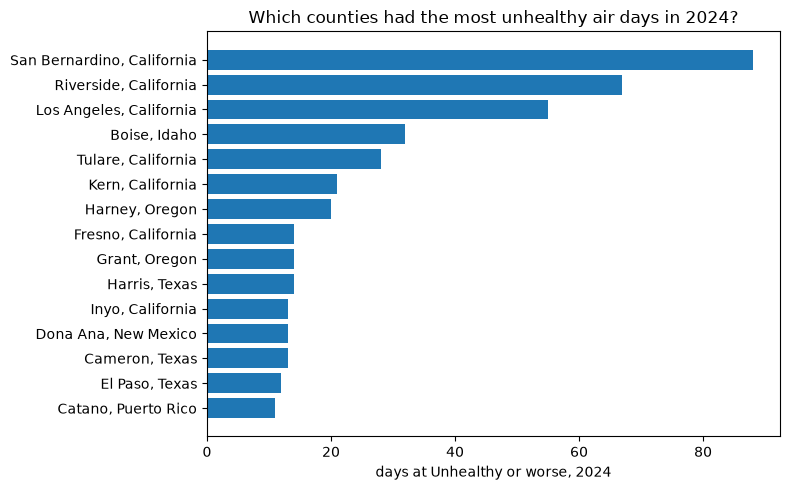

In [2]:
top15 = epa.nlargest(15, "unhealthy_total").iloc[::-1].copy()  # reversed: largest on top
top15["label"] = top15["County"] + ", " + top15["State"]

fig, ax = plt.subplots(figsize=(8, 5))
# YOUR CODE: horizontal bars of top15["unhealthy_total"] with top15["label"]
# on the y-axis; label both axes; give it a title that answers the question.

# reference chart (replace with your own):
ax.barh(top15["label"], top15["unhealthy_total"])
ax.set_xlabel("days at Unhealthy or worse, 2024")
ax.set_ylabel("")
ax.set_title("Which counties had the most unhealthy air days in 2024?")
plt.tight_layout()
plt.show()

### Finding 1 (three sentences, write here)

-
-
-

### Step 3 — Chart 2: the distribution of Median AQI (4 min)

Question: *is bad air a national condition or a local one?* Chart the
distribution of `Median AQI` across all 997 counties.

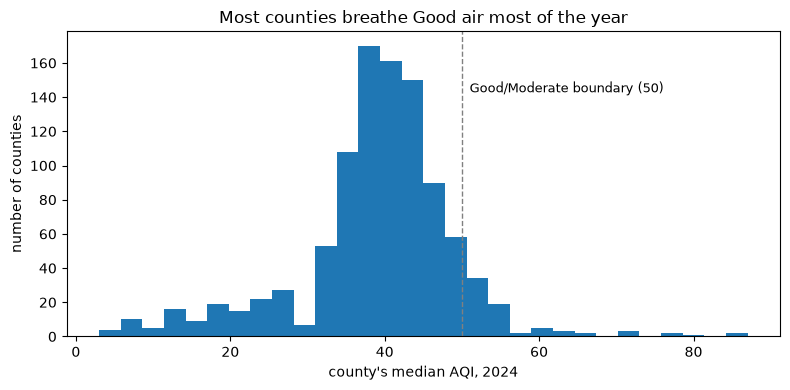

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
# YOUR CODE: a histogram of epa["Median AQI"] (bins ~30). Label the axes;
# consider a vertical line at AQI 50 (the Good/Moderate boundary).

# reference chart (replace with your own):
ax.hist(epa["Median AQI"], bins=30)
ax.axvline(50, color="grey", linestyle="--", linewidth=1)
ax.text(51, ax.get_ylim()[1] * 0.8, "Good/Moderate boundary (50)", fontsize=9)
ax.set_xlabel("county's median AQI, 2024")
ax.set_ylabel("number of counties")
ax.set_title("Most counties breathe Good air most of the year")
plt.tight_layout()
plt.show()

### Finding 2 (three sentences, write here)

-
-
-

### Step 4 — Chart 3: one state against the national median (5 min)

Question: *how does California compare?* Chart each California county's
`Median AQI` against the national median. (California has the most counties
in the file; swap in your own state if you prefer.)

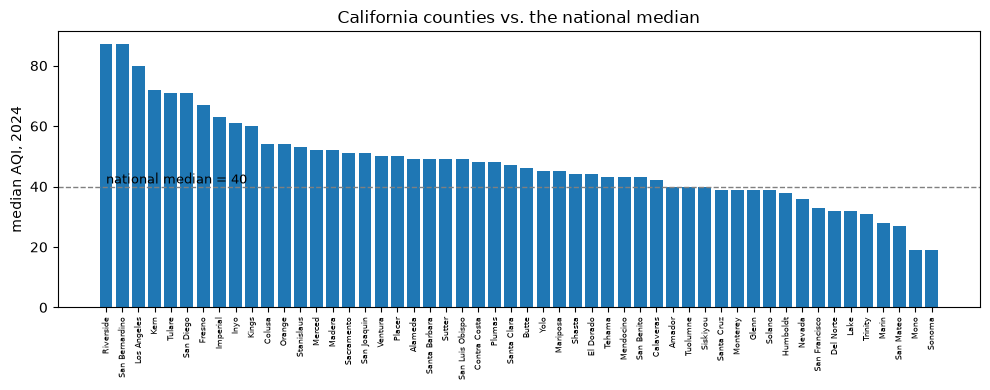

In [4]:
STATE = "California"
state_df = epa[epa["State"] == STATE].sort_values("Median AQI", ascending=False)
national_median = epa["Median AQI"].median()

fig, ax = plt.subplots(figsize=(10, 4))
# YOUR CODE: bars of Median AQI per county (sorted), with a horizontal line
# at national_median. X labels will be crowded — thin them or drop them.

# reference chart (replace with your own):
ax.bar(state_df["County"], state_df["Median AQI"])
ax.axhline(national_median, color="grey", linestyle="--", linewidth=1)
ax.text(0, national_median + 1, f"national median = {national_median:.0f}", fontsize=9)
ax.set_ylabel("median AQI, 2024")
ax.set_title(f"{STATE} counties vs. the national median")
ax.set_xticks(range(len(state_df)))
ax.set_xticklabels(state_df["County"], rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

### Finding 3 (three sentences, write here)

-
-
-

### Step 5 — The guideline checklist (4 min)

Before assembling the page, audit your three charts against the course
guidelines and fix what fails:

- [ ] Bars sorted by value (not alphabetically, not arbitrarily)
- [ ] Axes labelled with units; title states the question or the answer
- [ ] No chartjunk: no 3-D, no gradients, no gridline noise, no legend for
      a single series
- [ ] Honest scale: bar charts start at zero; any truncation is flagged in
      the title

### Step 6 — Three-sentence findings (5 min)

You drafted Finding 1–3 as you went. Revisit them now with the checklist in
hand: each finding should say what the chart shows, why it matters, and what
it does *not* show.

### Step 7 — Assemble the one-page briefing (5 min)

Question, three charts, recommendation — one figure, saved to
`epa_briefing.png`. The scaffold below stacks your three charts; polish it.

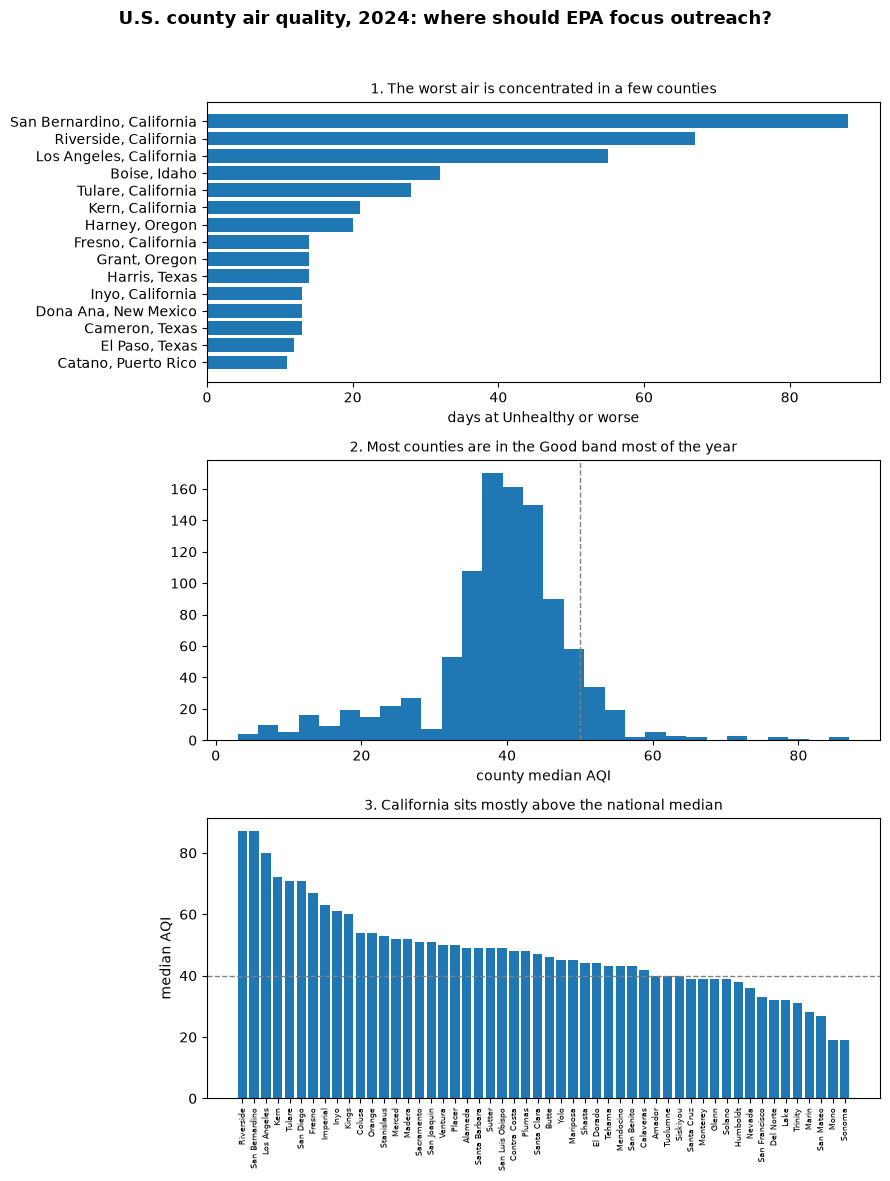

saved epa_briefing.png


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(9, 12))
fig.suptitle("U.S. county air quality, 2024: where should EPA focus outreach?",
             fontsize=13, fontweight="bold")

axes[0].barh(top15["label"], top15["unhealthy_total"])
axes[0].set_title("1. The worst air is concentrated in a few counties", fontsize=10)
axes[0].set_xlabel("days at Unhealthy or worse")

axes[1].hist(epa["Median AQI"], bins=30)
axes[1].axvline(50, color="grey", linestyle="--", linewidth=1)
axes[1].set_title("2. Most counties are in the Good band most of the year", fontsize=10)
axes[1].set_xlabel("county median AQI")

axes[2].bar(state_df["County"], state_df["Median AQI"])
axes[2].axhline(national_median, color="grey", linestyle="--", linewidth=1)
axes[2].set_title(f"3. {STATE} sits mostly above the national median", fontsize=10)
axes[2].set_ylabel("median AQI")
axes[2].set_xticks(range(len(state_df)))
axes[2].set_xticklabels(state_df["County"], rotation=90, fontsize=6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("epa_briefing.png", dpi=120)
plt.show()
print("saved epa_briefing.png")

### Recommendation (write here — one sentence the deputy director can act on)

-

## Deliverable

1. Three charts, each with its three-sentence finding.
2. The completed guideline checklist.
3. `epa_briefing.png` with your one-sentence recommendation.

## Reflection

1. Which chart would survive being screenshotted without its caption?
2. What did sorting change about the reader's conclusion?
3. What did you choose *not* to plot, and why?

## Debrief (instructor-led)

1. Which chart would you hand a reporter, and which an inspector general?
   What changes between the two?
2. The one-pager answers "where should we focus" — what does it deliberately
   leave out, and who might object?
3. If this briefing ran every month, what would you automate — and what must
   stay human?

## Troubleshooting

- **X-axis labels are unreadable** — rotate them (`rotation=90`, small font),
  thin them (show every nth), or switch to horizontal bars.
- **`plt.savefig` produces a blank image** — you called `plt.show()` first;
  `show()` clears the figure. Save first, then show (Step 7 does).
- **`KeyError: 'Median AQI'`** — the load cell (Step 1) was not run; run the
  notebook in order. Column names have spaces, so use `epa["Median AQI"]`,
  not dot notation.
- **Bars look sorted but are not** — `nlargest` picks the top N but you must
  reverse (`.iloc[::-1]`) for `barh` to put the largest on top.
- **The histogram's boundary line label sits off-screen** — place text with
  `ax.get_ylim()` fractions after drawing the histogram, as in the reference.